In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
!cd drive/MyDrive/ColabProjects/SpectrumTune

In [4]:
import sys
sys.path.append('/content/drive/MyDrive/ColabProjects/SpectrumTune')

In [5]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

class GTZANSpectrogramDataset(Dataset):
    def __init__(self, spectrogram_dir, transform=None):
        self.spectrogram_dir = spectrogram_dir
        self.transform = transform

        # Get all genres (subdirectories)
        self.genres = sorted([d for d in os.listdir(spectrogram_dir)
                     if os.path.isdir(os.path.join(spectrogram_dir, d))])
        self.genre_to_idx = {genre: i for i, genre in enumerate(self.genres)}

        # Collect all file paths and corresponding labels
        self.file_paths = []
        self.labels = []

        for genre in self.genres:
            genre_dir = os.path.join(spectrogram_dir, genre)
            for filename in os.listdir(genre_dir):
                if filename.endswith('.png') or filename.endswith('.jpg'):
                    self.file_paths.append(os.path.join(genre_dir, filename))
                    self.labels.append(self.genre_to_idx[genre])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Define transformations for images
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet expects 224x224 input
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats
])


DATASET_PATH = '/content/drive/MyDrive/ColabProjects/SpectrumTune/data/GTZAN'
SPECTROGRAM_DIR = os.path.join(DATASET_PATH, 'images_original')
FEATURES_CSV = os.path.join(DATASET_PATH, 'features_30_sec.csv')
dataset = GTZANSpectrogramDataset(spectrogram_dir=SPECTROGRAM_DIR, transform=transform)

# Split into train, validation, and test sets (70/15/15)
generator = torch.Generator().manual_seed(42)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size], generator=generator
)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Number of genres: {len(dataset.genres)}")
print(f"Genres: {dataset.genres}")
print(f"Total samples: {len(dataset)}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Number of genres: 10
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Total samples: 999
Training samples: 699
Validation samples: 149
Test samples: 151


In [7]:
# 1. Define the GenreClassifier with different freezing strategies
import torch
import torch.nn as nn
import torchvision.models as models

class GenreClassifier(nn.Module):
    """ResNet50-based model for music genre classification with configurable layer freezing"""

    def __init__(self, num_classes=10, pretrained=True, freeze_strategy='all'):
        """
        Args:
            num_classes (int): Number of output classes (genres)
            pretrained (bool): Whether to use pretrained weights
            freeze_strategy (str): One of 'all', 'layer4', 'layer3', 'layer2', 'none'
        """
        super(GenreClassifier, self).__init__()

        # Load pre-trained ResNet50
        self.model = models.resnet50(weights='IMAGENET1K_V2' if pretrained else None)

        # Apply freezing based on strategy
        self.apply_freezing_strategy(freeze_strategy)

        # Replace the final fully connected layer
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Linear(num_ftrs, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

    def apply_freezing_strategy(self, strategy):
        """Apply the specified freezing strategy to the model"""
        # First unfreeze everything
        for param in self.model.parameters():
            param.requires_grad = True

        if strategy == 'all':
            # Freeze all layers except final FC
            for name, param in self.model.named_parameters():
                if 'fc' not in name:
                    param.requires_grad = False

        elif strategy == 'layer4':
            # Freeze all layers except layer4 and FC
            for name, param in self.model.named_parameters():
                if 'layer4' not in name and 'fc' not in name:
                    param.requires_grad = False

        elif strategy == 'layer3':
            # Freeze all layers except layer3, layer4 and FC
            for name, param in self.model.named_parameters():
                if 'layer3' not in name and 'layer4' not in name and 'fc' not in name:
                    param.requires_grad = False

        elif strategy == 'layer2':
            # Freeze all layers except layer2, layer3, layer4 and FC
            for name, param in self.model.named_parameters():
                if 'layer2' not in name and 'layer3' not in name and 'layer4' not in name and 'fc' not in name:
                    param.requires_grad = False

        elif strategy == 'none':
            # Don't freeze any layers - already set all to trainable above
            pass

        else:
            raise ValueError(f"Unsupported freeze strategy: {strategy}")

    def print_trainable_parameters(self):
        """Print which parameters are trainable and the total count"""
        trainable_params = 0
        all_params = 0

        # Print each trainable parameter
        print("Trainable layers:")
        for name, param in self.model.named_parameters():
            all_params += param.numel()
            if param.requires_grad:
                trainable_params += param.numel()
                print(f"  {name}")

        print(f"\nTrainable parameters: {trainable_params:,} ({100 * trainable_params / all_params:.2f}%)")
        print(f"Frozen parameters: {all_params - trainable_params:,} ({100 * (all_params - trainable_params) / all_params:.2f}%)")
        print(f"Total parameters: {all_params:,}")

In [8]:
# 2. Define training and evaluation functions
import torch.optim as optim
from tqdm.notebook import tqdm

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [10]:

import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def run_experiment(freeze_strategy, learning_rate=0.001, num_epochs=15):
    """
    Run a complete experiment for a specific freezing strategy

    Args:
        freeze_strategy (str): Which freezing strategy to use
        learning_rate (float): Learning rate for optimizer
        num_epochs (int): Number of training epochs

    Returns:
        tuple: (history, test_acc, confusion matrix)
    """

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")


    experiment_name = f"resnet50_{freeze_strategy}"
    print(f"\n{'='*50}")
    print(f"EXPERIMENT: {experiment_name}")
    print(f"{'='*50}\n")


    model = GenreClassifier(num_classes=len(dataset.genres), pretrained=True, freeze_strategy=freeze_strategy)
    model = model.to(device)


    model.print_trainable_parameters()


    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)


    os.makedirs('models', exist_ok=True)
    save_path = f'models/{experiment_name}_best.pth'


    best_val_acc = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")


        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")


        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


        scheduler.step(val_loss)


        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)


        if val_acc > best_val_acc:
            best_val_acc = val_acc
            print(f"New best model with validation accuracy: {val_acc:.4f}")
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_acc': val_acc,
                'freeze_strategy': freeze_strategy
            }, save_path)


    checkpoint = torch.load(save_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\nLoaded best model from epoch {checkpoint['epoch']+1} with validation accuracy: {checkpoint['val_acc']:.4f}")


    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")


    all_preds = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)


    print("\nClassification Report:")
    report = classification_report(all_labels, all_preds, target_names=dataset.genres)
    print(report)


    plot_training_curves(history, experiment_name, test_acc)


    plot_confusion_matrix(cm, dataset.genres, experiment_name)

    return history, test_acc, cm

def plot_training_curves(history, experiment_name, test_acc=None):
    """Plot training and validation curves with experiment details"""

    plt.figure(figsize=(15, 6))


    plt.suptitle(f'Model: {experiment_name}', fontsize=16)


    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], marker='o', linestyle='-', label='Train')
    plt.plot(history['val_loss'], marker='o', linestyle='-', label='Validation')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()


    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], marker='o', linestyle='-', label='Train')
    plt.plot(history['val_acc'], marker='o', linestyle='-', label='Validation')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)
    plt.legend()


    if test_acc is not None:
        plt.figtext(0.5, 0.01, f"Test Accuracy: {test_acc:.4f}",
                   ha="center", fontsize=12,
                   bbox={"facecolor":"lightgray", "alpha":0.5, "pad":5})

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f'{experiment_name}_training_curves.png')
    plt.show()

def plot_confusion_matrix(cm, class_names, experiment_name):
    """Plot confusion matrix as a heatmap"""
    plt.figure(figsize=(10, 8))


    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.title(f'Confusion Matrix - {experiment_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{experiment_name}_confusion_matrix.png')
    plt.show()

Using device: cuda

EXPERIMENT: resnet50_all



Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


Trainable layers:
  fc.0.weight
  fc.0.bias
  fc.3.weight
  fc.3.bias

Trainable parameters: 527,114 (2.19%)
Frozen parameters: 23,508,032 (97.81%)
Total parameters: 24,035,146

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training:   0%|          | 0/22 [00:00<?, ?it/s]

...

Train Loss: 0.2394, Train Acc: 0.9657


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

Val Loss: 1.1245, Val Acc: 0.5906

Loaded best model from epoch 18 with validation accuracy: 0.6443


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

Test Loss: 1.2330, Test Acc: 0.5364

Classification Report:
              precision    recall  f1-score   support

       blues       0.41      0.44      0.42        16
   classical       1.00      0.73      0.84        11
     country       0.39      0.37      0.38        19
       disco       0.35      0.33      0.34        21
      hiphop       0.59      0.77      0.67        13
        jazz       0.77      0.83      0.80        12
       metal       0.71      1.00      0.83        12
         pop       0.56      0.59      0.57        17
      reggae       0.50      0.47      0.48        15
        rock       0.33      0.20      0.25        15

    accuracy                           0.54       151
   macro avg       0.56      0.57      0.56       151
weighted avg       0.53      0.54      0.53       151



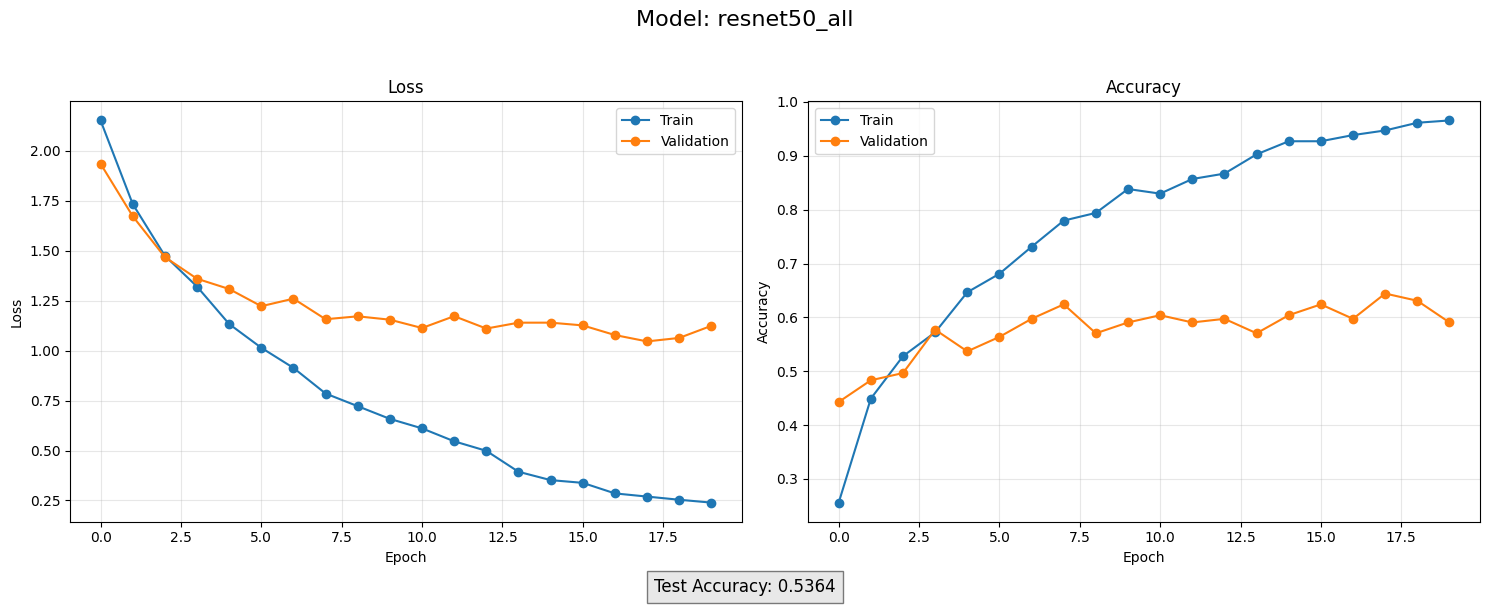

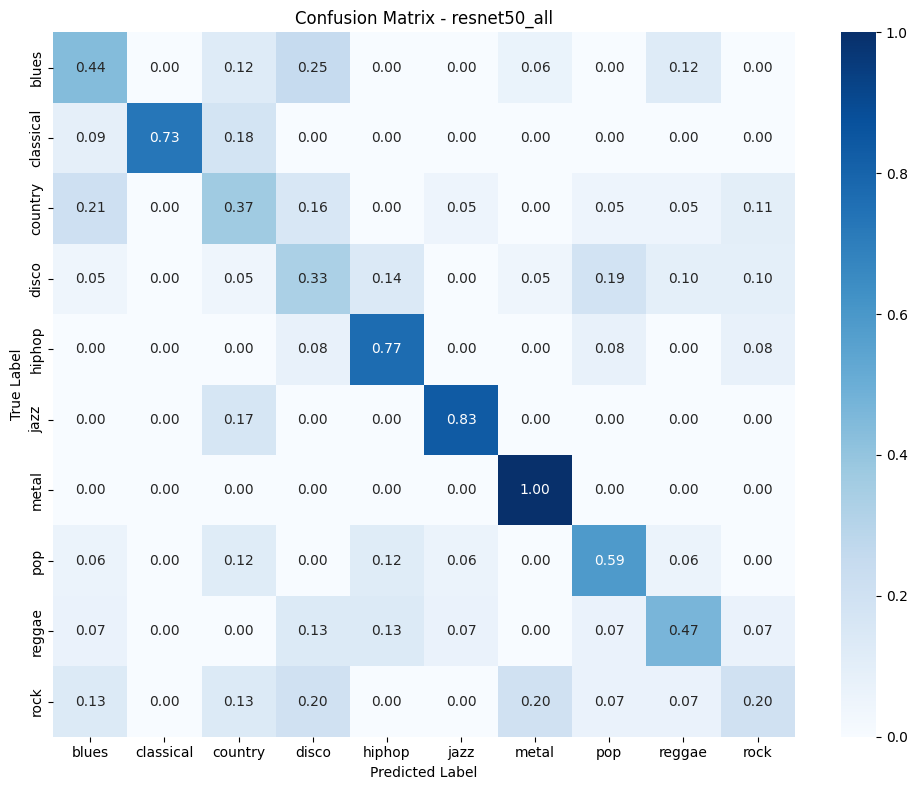

Using device: cuda

EXPERIMENT: resnet50_layer4

Trainable layers:
  layer4.0.conv1.weight
  layer4.0.bn1.weight
  layer4.0.bn1.bias
  layer4.0.conv2.weight
  layer4.0.bn2.weight
  layer4.0.bn2.bias
  layer4.0.conv3.weight
  layer4.0.bn3.weight
  layer4.0.bn3.bias
  layer4.0.downsample.0.weight
  layer4.0.downsample.1.weight
  layer4.0.downsample.1.bias
  layer4.1.conv1.weight
  layer4.1.bn1.weight
  layer4.1.bn1.bias
  layer4.1.conv2.weight
  layer4.1.bn2.weight
  layer4.1.bn2.bias
  layer4.1.conv3.weight
  layer4.1.bn3.weight
  layer4.1.bn3.bias
  layer4.2.conv1.weight
  layer4.2.bn1.weight
  layer4.2.bn1.bias
  layer4.2.conv2.weight
  layer4.2.bn2.weight
  layer4.2.bn2.bias
  layer4.2.conv3.weight
  layer4.2.bn3.weight
  layer4.2.bn3.bias
  fc.0.weight
  fc.0.bias
  fc.3.weight
  fc.3.bias

Trainable parameters: 15,491,850 (64.45%)
Frozen parameters: 8,543,296 (35.55%)
Total parameters: 24,035,146

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training:   0%|          | 0/22 [00:00<?, ?it/s]

Train Loss: 1.8405, Train Acc: 0.3405


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

...

Train Loss: 0.0032, Train Acc: 1.0000


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

Val Loss: 1.1237, Val Acc: 0.7450

Loaded best model from epoch 14 with validation accuracy: 0.7517


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

Test Loss: 1.3582, Test Acc: 0.6291

Classification Report:
              precision    recall  f1-score   support

       blues       0.67      0.50      0.57        16
   classical       0.83      0.91      0.87        11
     country       0.50      0.58      0.54        19
       disco       0.56      0.48      0.51        21
      hiphop       0.67      0.77      0.71        13
        jazz       0.83      0.83      0.83        12
       metal       0.67      1.00      0.80        12
         pop       0.68      0.76      0.72        17
      reggae       0.64      0.47      0.54        15
        rock       0.33      0.27      0.30        15

    accuracy                           0.63       151
   macro avg       0.64      0.66      0.64       151
weighted avg       0.62      0.63      0.62       151



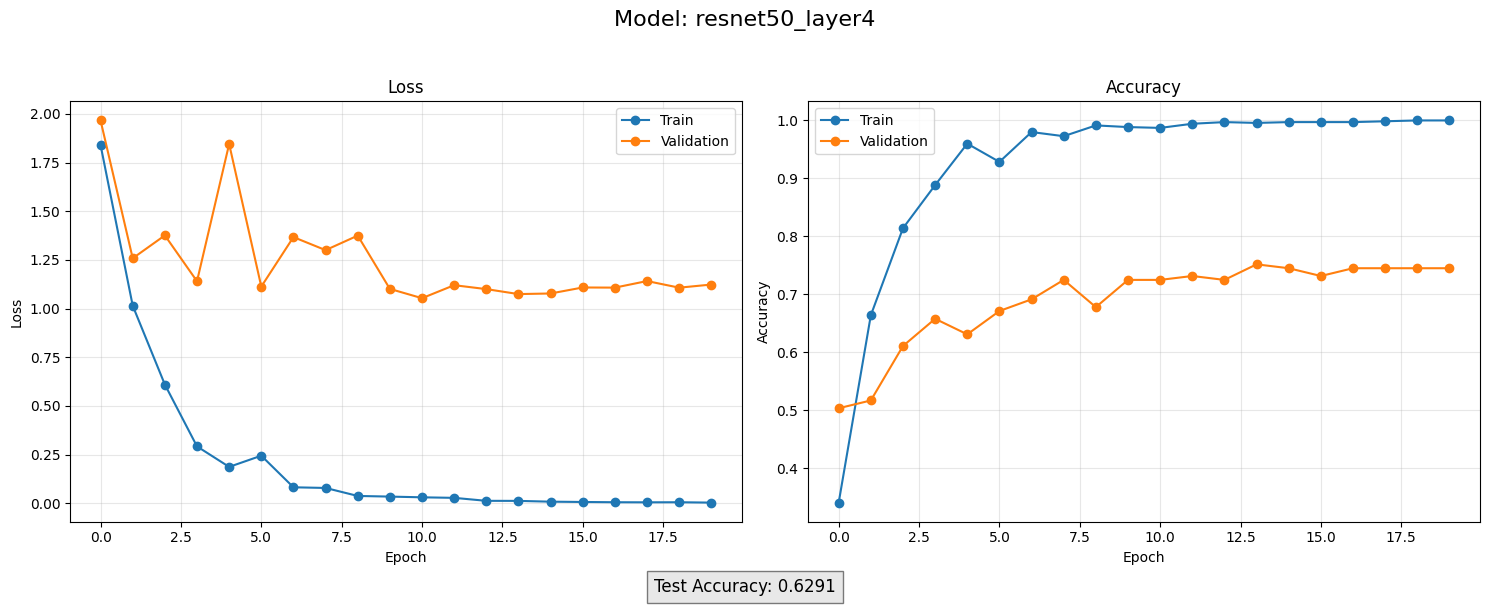

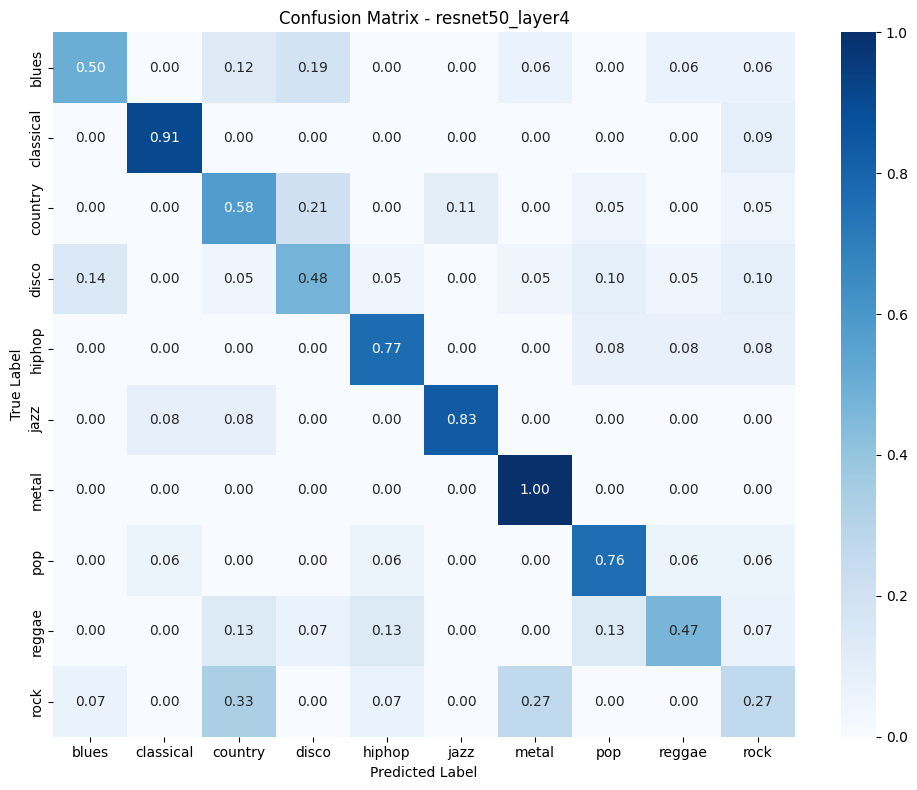

Using device: cuda

EXPERIMENT: resnet50_layer3

Trainable layers:
  layer3.0.conv1.weight
  layer3.0.bn1.weight
  layer3.0.bn1.bias
  layer3.0.conv2.weight
  layer3.0.bn2.weight
  layer3.0.bn2.bias
  layer3.0.conv3.weight
  layer3.0.bn3.weight
  layer3.0.bn3.bias
  layer3.0.downsample.0.weight
  layer3.0.downsample.1.weight
  layer3.0.downsample.1.bias
  layer3.1.conv1.weight
  layer3.1.bn1.weight
  layer3.1.bn1.bias
  layer3.1.conv2.weight
  layer3.1.bn2.weight
  layer3.1.bn2.bias
  layer3.1.conv3.weight
  layer3.1.bn3.weight
  layer3.1.bn3.bias
  layer3.2.conv1.weight
  layer3.2.bn1.weight
  layer3.2.bn1.bias
  layer3.2.conv2.weight
  layer3.2.bn2.weight
  layer3.2.bn2.bias
  layer3.2.conv3.weight
  layer3.2.bn3.weight
  layer3.2.bn3.bias
  layer3.3.conv1.weight
  layer3.3.bn1.weight
  layer3.3.bn1.bias
  layer3.3.conv2.weight
  layer3.3.bn2.weight
  layer3.3.bn2.bias
  layer3.3.conv3.weight
  layer3.3.bn3.weight
  layer3.3.bn3.bias
  layer3.4.conv1.weight
  layer3.4.bn1.weight
  la

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training:   0%|          | 0/22 [00:00<?, ?it/s]

Train Loss: 1.8436, Train Acc: 0.3462


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

...

Train Loss: 0.0042, Train Acc: 0.9986


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

Val Loss: 0.9339, Val Acc: 0.8188

Loaded best model from epoch 9 with validation accuracy: 0.8188


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

Test Loss: 1.2318, Test Acc: 0.7020

Classification Report:
              precision    recall  f1-score   support

       blues       0.64      0.56      0.60        16
   classical       0.64      0.82      0.72        11
     country       0.71      0.53      0.61        19
       disco       0.65      0.81      0.72        21
      hiphop       0.91      0.77      0.83        13
        jazz       0.91      0.83      0.87        12
       metal       0.85      0.92      0.88        12
         pop       0.76      0.76      0.76        17
      reggae       0.77      0.67      0.71        15
        rock       0.39      0.47      0.42        15

    accuracy                           0.70       151
   macro avg       0.72      0.71      0.71       151
weighted avg       0.71      0.70      0.70       151



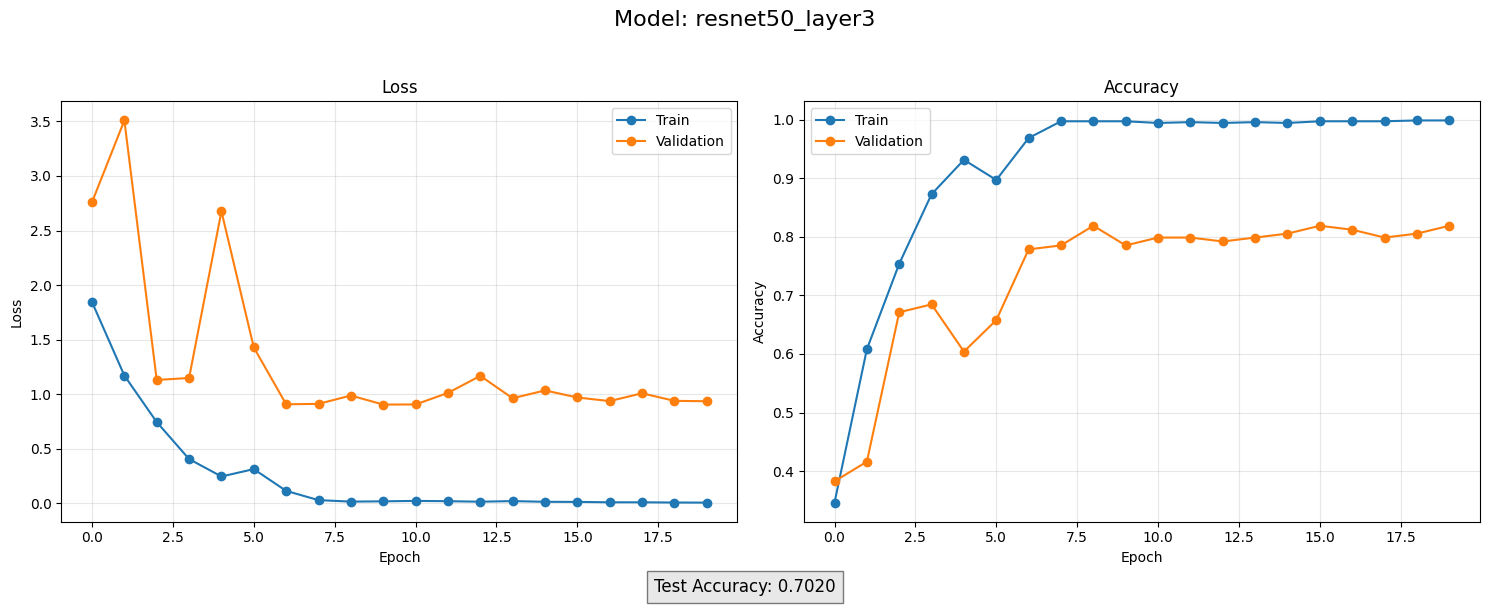

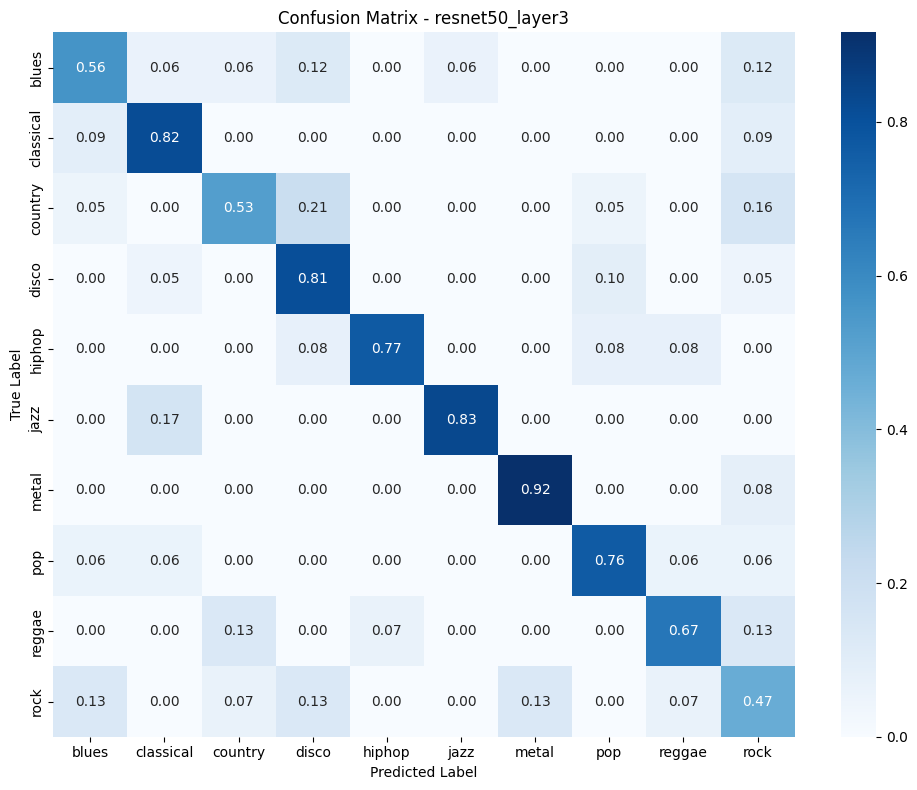

Using device: cuda

EXPERIMENT: resnet50_layer2

Trainable layers:
  layer2.0.conv1.weight
  layer2.0.bn1.weight
  layer2.0.bn1.bias
  layer2.0.conv2.weight
  layer2.0.bn2.weight
  layer2.0.bn2.bias
  layer2.0.conv3.weight
  layer2.0.bn3.weight
  layer2.0.bn3.bias
  layer2.0.downsample.0.weight
  layer2.0.downsample.1.weight
  layer2.0.downsample.1.bias
  layer2.1.conv1.weight
  layer2.1.bn1.weight
  layer2.1.bn1.bias
  layer2.1.conv2.weight
  layer2.1.bn2.weight
  layer2.1.bn2.bias
  layer2.1.conv3.weight
  layer2.1.bn3.weight
  layer2.1.bn3.bias
  layer2.2.conv1.weight
  layer2.2.bn1.weight
  layer2.2.bn1.bias
  layer2.2.conv2.weight
  layer2.2.bn2.weight
  layer2.2.bn2.bias
  layer2.2.conv3.weight
  layer2.2.bn3.weight
  layer2.2.bn3.bias
  layer2.3.conv1.weight
  layer2.3.bn1.weight
  layer2.3.bn1.bias
  layer2.3.conv2.weight
  layer2.3.bn2.weight
  layer2.3.bn2.bias
  layer2.3.conv3.weight
  layer2.3.bn3.weight
  layer2.3.bn3.bias
  layer3.0.conv1.weight
  layer3.0.bn1.weight
  la

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training:   0%|          | 0/22 [00:00<?, ?it/s]

Train Loss: 1.8850, Train Acc: 0.3376


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

...

Train Loss: 0.0080, Train Acc: 0.9986


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

Val Loss: 0.7171, Val Acc: 0.8255

Loaded best model from epoch 13 with validation accuracy: 0.8322


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

Test Loss: 1.3413, Test Acc: 0.7020

Classification Report:
              precision    recall  f1-score   support

       blues       0.69      0.56      0.62        16
   classical       0.83      0.91      0.87        11
     country       0.67      0.32      0.43        19
       disco       0.70      0.76      0.73        21
      hiphop       0.91      0.77      0.83        13
        jazz       0.79      0.92      0.85        12
       metal       0.63      1.00      0.77        12
         pop       0.70      0.82      0.76        17
      reggae       0.73      0.73      0.73        15
        rock       0.47      0.47      0.47        15

    accuracy                           0.70       151
   macro avg       0.71      0.73      0.71       151
weighted avg       0.70      0.70      0.69       151



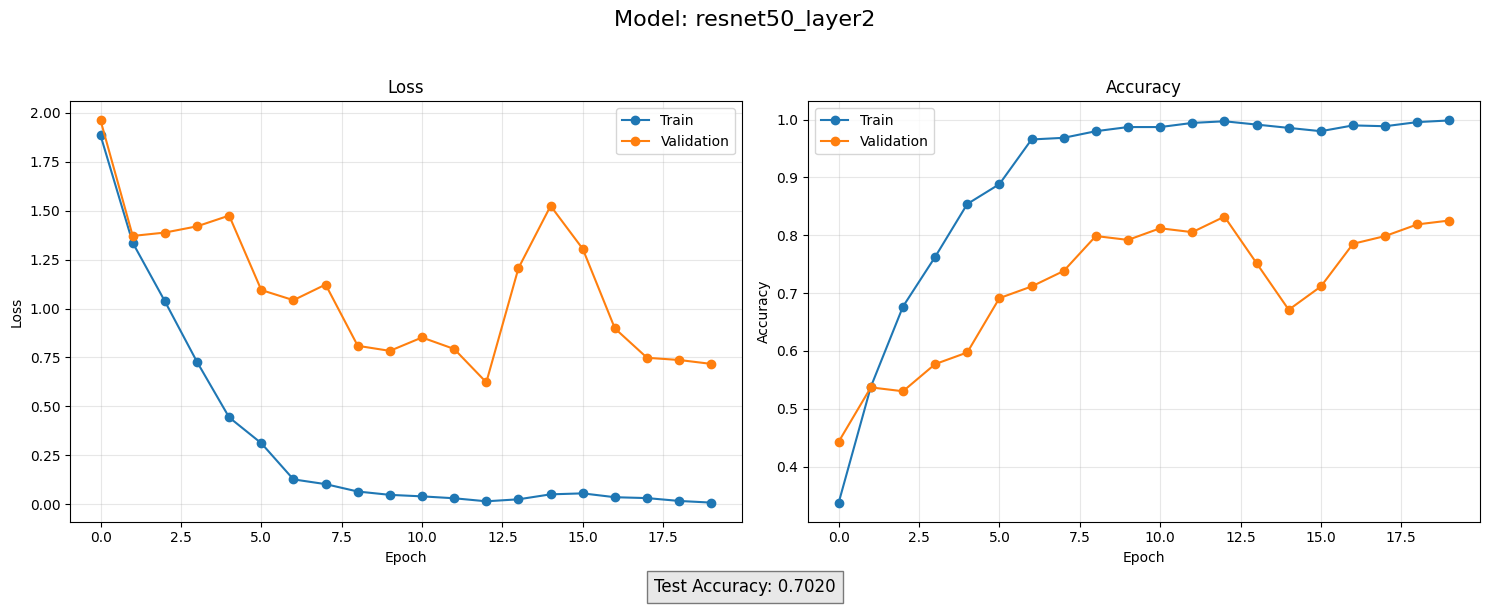

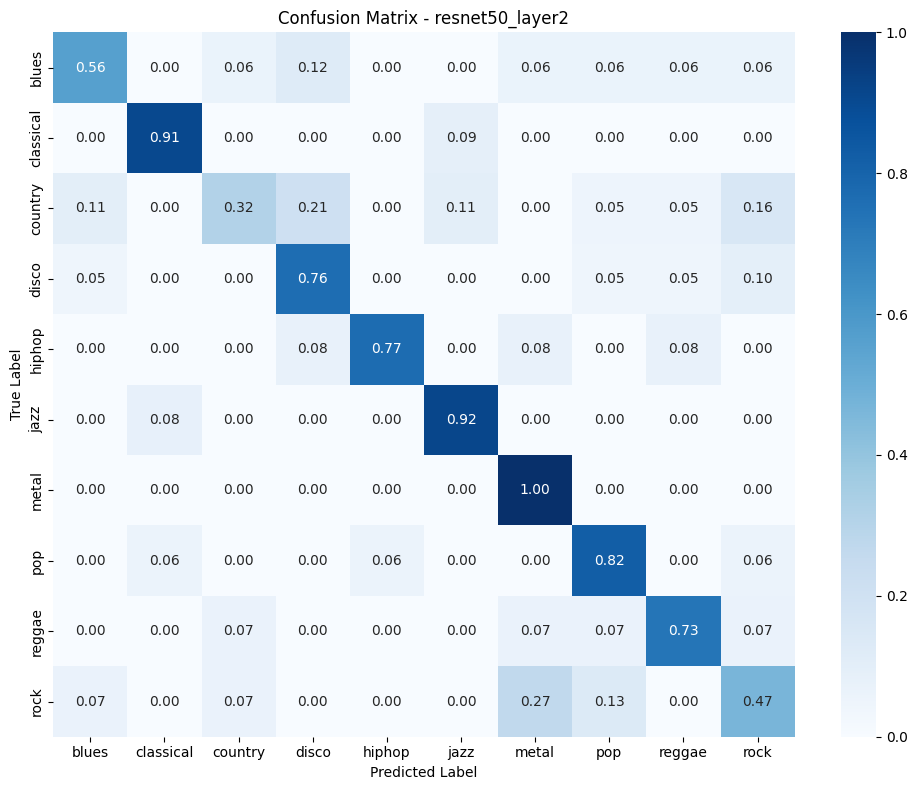

Using device: cuda

EXPERIMENT: resnet50_none

Trainable layers:
  conv1.weight
  bn1.weight
  bn1.bias
  layer1.0.conv1.weight
  layer1.0.bn1.weight
  layer1.0.bn1.bias
  layer1.0.conv2.weight
  layer1.0.bn2.weight
  layer1.0.bn2.bias
  layer1.0.conv3.weight
  layer1.0.bn3.weight
  layer1.0.bn3.bias
  layer1.0.downsample.0.weight
  layer1.0.downsample.1.weight
  layer1.0.downsample.1.bias
  layer1.1.conv1.weight
  layer1.1.bn1.weight
  layer1.1.bn1.bias
  layer1.1.conv2.weight
  layer1.1.bn2.weight
  layer1.1.bn2.bias
  layer1.1.conv3.weight
  layer1.1.bn3.weight
  layer1.1.bn3.bias
  layer1.2.conv1.weight
  layer1.2.bn1.weight
  layer1.2.bn1.bias
  layer1.2.conv2.weight
  layer1.2.bn2.weight
  layer1.2.bn2.bias
  layer1.2.conv3.weight
  layer1.2.bn3.weight
  layer1.2.bn3.bias
  layer2.0.conv1.weight
  layer2.0.bn1.weight
  layer2.0.bn1.bias
  layer2.0.conv2.weight
  layer2.0.bn2.weight
  layer2.0.bn2.bias
  layer2.0.conv3.weight
  layer2.0.bn3.weight
  layer2.0.bn3.bias
  layer2.0.do

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training:   0%|          | 0/22 [00:00<?, ?it/s]

Train Loss: 1.8180, Train Acc: 0.3305


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

...

Train Loss: 0.0055, Train Acc: 0.9971


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

Val Loss: 0.6388, Val Acc: 0.8523
New best model with validation accuracy: 0.8523

Loaded best model from epoch 20 with validation accuracy: 0.8523


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

Test Loss: 1.2283, Test Acc: 0.7616

Classification Report:
              precision    recall  f1-score   support

       blues       0.80      0.75      0.77        16
   classical       0.83      0.91      0.87        11
     country       0.69      0.47      0.56        19
       disco       0.64      0.76      0.70        21
      hiphop       0.91      0.77      0.83        13
        jazz       1.00      1.00      1.00        12
       metal       0.85      0.92      0.88        12
         pop       0.74      0.82      0.78        17
      reggae       0.73      0.73      0.73        15
        rock       0.62      0.67      0.65        15

    accuracy                           0.76       151
   macro avg       0.78      0.78      0.78       151
weighted avg       0.76      0.76      0.76       151



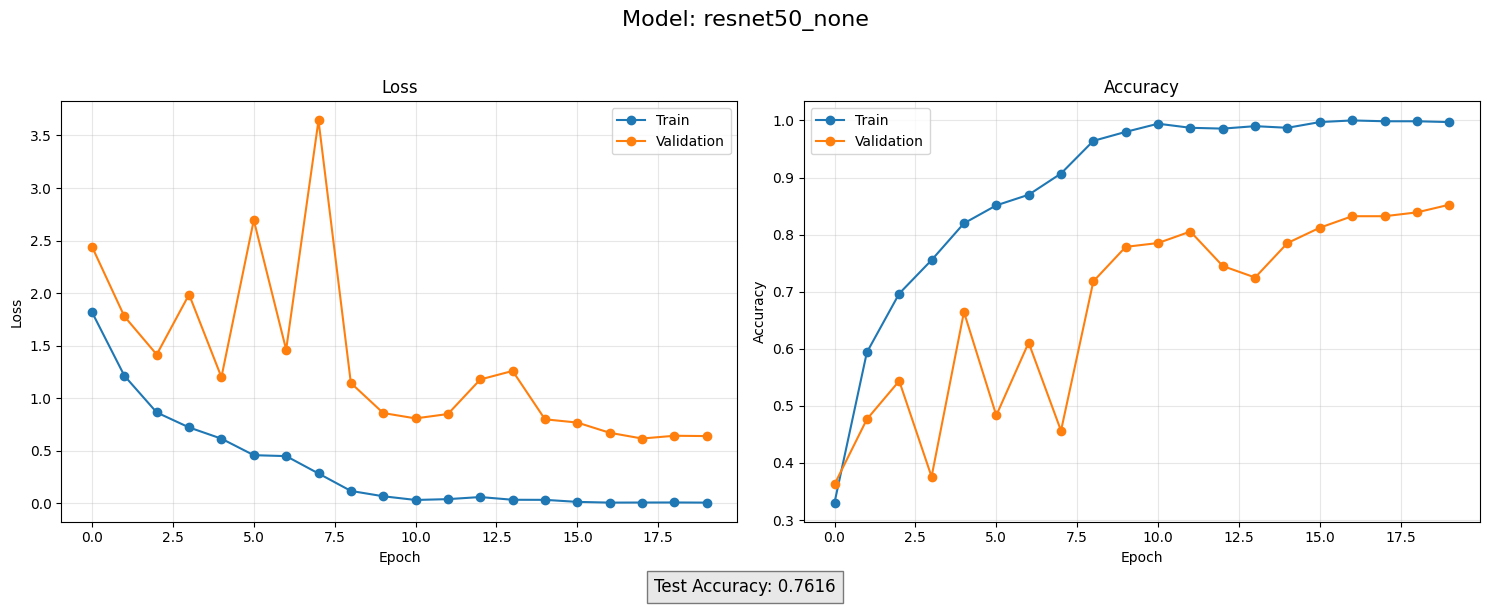

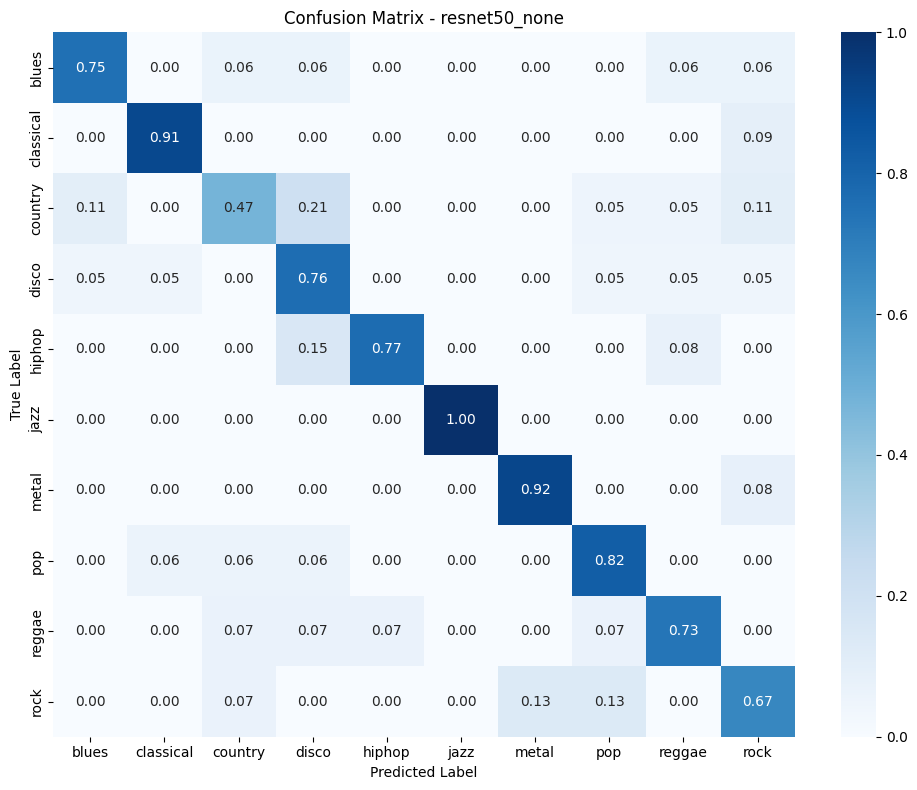

In [11]:

freeze_strategies = ['all', 'layer4', 'layer3', 'layer2', 'none']
results = {}


for strategy in freeze_strategies:
    history, test_acc, cm = run_experiment(
        freeze_strategy=strategy,
        learning_rate=0.001,
        num_epochs=20
    )

    results[strategy] = {
        'history': history,
        'test_acc': test_acc,
        'confusion_matrix': cm
    }

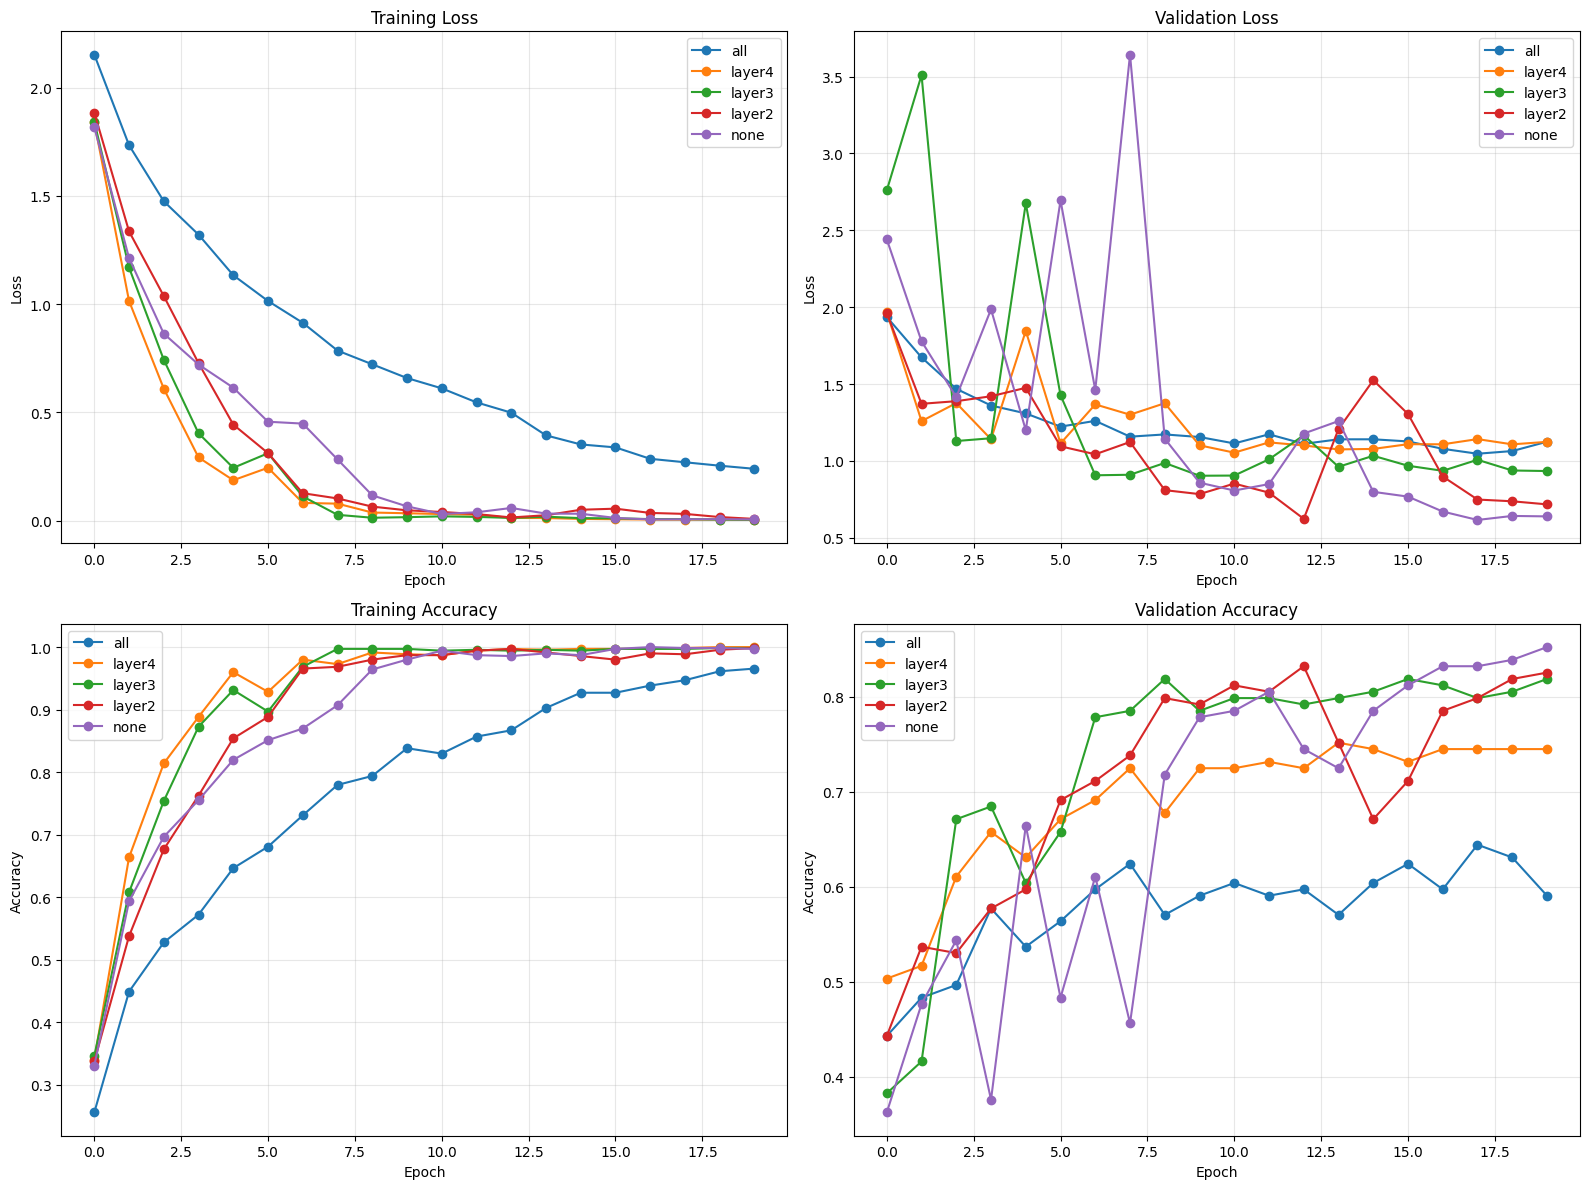

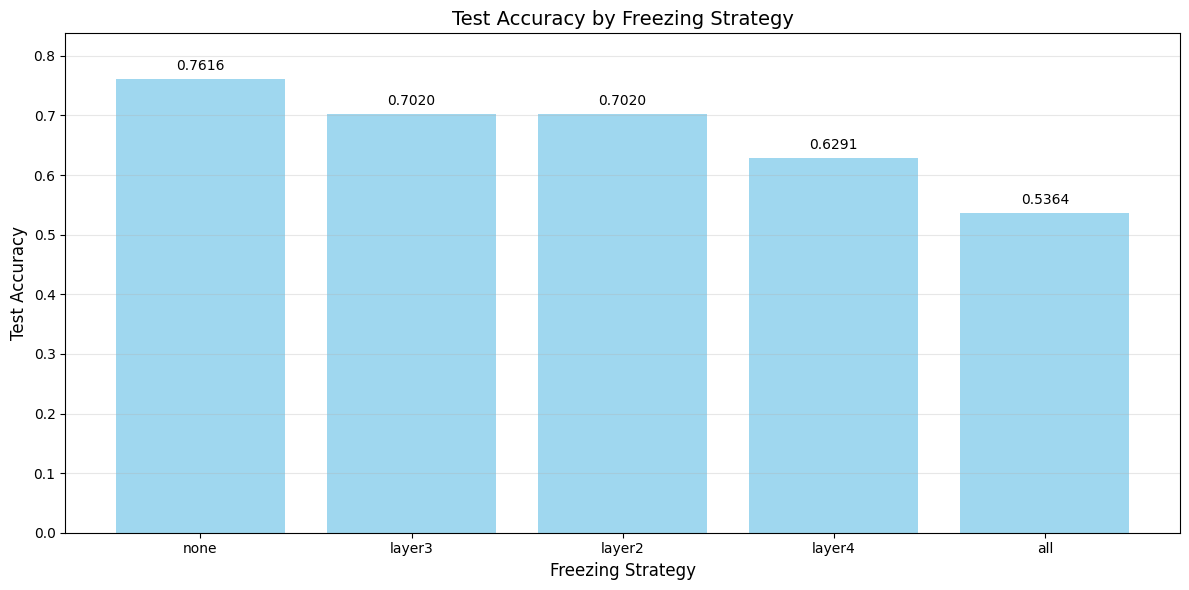

In [12]:
# 5. Compare results across all freezing strategies
def plot_comparative_results(results):
    """Generate visualizations comparing all freezing strategies"""

    plt.figure(figsize=(16, 12))


    plt.subplot(2, 2, 1)
    for strategy, result in results.items():
        plt.plot(result['history']['train_loss'], marker='o', linestyle='-', label=strategy)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()


    plt.subplot(2, 2, 2)
    for strategy, result in results.items():
        plt.plot(result['history']['val_loss'], marker='o', linestyle='-', label=strategy)
    plt.title('Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()


    plt.subplot(2, 2, 3)
    for strategy, result in results.items():
        plt.plot(result['history']['train_acc'], marker='o', linestyle='-', label=strategy)
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)
    plt.legend()


    plt.subplot(2, 2, 4)
    for strategy, result in results.items():
        plt.plot(result['history']['val_acc'], marker='o', linestyle='-', label=strategy)
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig('comparative_training_curves.png')
    plt.show()


    plt.figure(figsize=(12, 6))


    sorted_strategies = sorted(results.keys(), key=lambda x: results[x]['test_acc'], reverse=True)
    test_accuracies = [results[s]['test_acc'] for s in sorted_strategies]


    bars = plt.bar(sorted_strategies, test_accuracies, color='skyblue', alpha=0.8)


    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

    plt.title('Test Accuracy by Freezing Strategy', fontsize=14)
    plt.xlabel('Freezing Strategy', fontsize=12)
    plt.ylabel('Test Accuracy', fontsize=12)
    plt.ylim(0, max(test_accuracies) * 1.1)  # Add some space above bars
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('comparative_test_accuracy.png')
    plt.show()


plot_comparative_results(results)

In [13]:
# 6. Draw conclusions and identify best strategy
best_strategy = max(results.keys(), key=lambda s: results[s]['test_acc'])
best_acc = results[best_strategy]['test_acc']

print(f"\n{'='*50}")
print(f"EXPERIMENT RESULTS SUMMARY")
print(f"{'='*50}")
print(f"Best freezing strategy: {best_strategy}")
print(f"Best test accuracy: {best_acc:.4f}")
print("\nTest accuracies for all strategies:")
for strategy in sorted(results.keys(), key=lambda s: results[s]['test_acc'], reverse=True):
    print(f"  {strategy}: {results[strategy]['test_acc']:.4f}")


import json
with open('freezing_experiment_results.json', 'w') as f:

    serializable_results = {}
    for strategy, data in results.items():
        serializable_results[strategy] = {
            'history': {
                'train_loss': [float(x) for x in data['history']['train_loss']],
                'val_loss': [float(x) for x in data['history']['val_loss']],
                'train_acc': [float(x) for x in data['history']['train_acc']],
                'val_acc': [float(x) for x in data['history']['val_acc']]
            },
            'test_acc': float(data['test_acc']),
            'confusion_matrix': data['confusion_matrix'].tolist()
        }
    json.dump(serializable_results, f, indent=2)



EXPERIMENT RESULTS SUMMARY
Best freezing strategy: none
Best test accuracy: 0.7616

Test accuracies for all strategies:
  none: 0.7616
  layer3: 0.7020
  layer2: 0.7020
  layer4: 0.6291
  all: 0.5364
